Sources:
(https://www.rdkit.org/docs/source/rdkit.Chem.rdMolDescriptors.html)
https://www.rdkit.org/docs/GettingStartedInPython.html#substructure-searches

In [2]:
import pandas as pd
from rdkit import Chem
from sklearn.preprocessing import OneHotEncoder

#Including imports for plotting - Sana
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
#import linker data and resolve UnicodeDecodeError
linker = pd.read_csv('data/linkers.csv', encoding = 'latin1')
#convert SMILES to RDKit, remove invalid entries
linker = linker.assign(molecule = linker['smiles'].apply(Chem.MolFromSmiles)).query('molecule.notnull()')
#create canonical smiles so that all versions of same molecule maps to the same SMILES string
linker['smiles'] = linker['molecule'].apply(Chem.MolToSmiles)
#remove duplicate values

#use one hot encoding -- needed for later
linker_encoder = OneHotEncoder(sparse_output = False)
encoded_linker = linker_encoder.fit_transform(linker[['source']])
encoded = pd.DataFrame(encoded_linker, columns = linker_encoder.get_feature_names_out(['source']))
#join both the linker and OHE data
concat_linker = pd.concat([linker.reset_index(drop = True), encoded.reset_index(drop = True)], axis = 1)
concat_linker.head()

,Unnamed: 0.2,Unnamed: 0,Unnamed: 0.1,Product name,smiles,calc_SA_score,TPSA,QED,LogP,Molecular Weight,K-means,scaffold_smiles,source,molecule,source_train,source_val
0,0,0,0,(Ac)Phe-Lys(Alloc)-PABC-PNP,C=CCOC(=O)NCCCC[C@H](NC(=O)[C@H](Cc1ccccc1)NC(...,3.508295,204.30,0.036588,4.5636,689.72,12,O=C(CCc1ccccc1)NCC(=O)Nc1ccc(COC(=O)Oc2ccccc2)cc1,train,<rdkit.Chem.rdchem.Mol object at 0x12a87c6d0>,1.0,0.0
1,1,1,1,6-Maleimidohexanoic acid N-hydroxysuccinimide ...,O=C(CCCCCN1C(=O)C=CC1=O)ON1C(=O)CCC1=O,2.676214,101.06,0.487410,0.0790,308.29,4,O=C(CCCCCN1C(=O)C=CC1=O)ON1C(=O)CCC1=O,train,<rdkit.Chem.rdchem.Mol object at 0x12a87c740>,1.0,0.0
2,2,2,2,Fmoc-Val-Cit-PAB,CC(C)[C@H](NC(=O)OCC1c2ccccc2-c2ccccc21)C(=O)N...,3.338596,171.88,0.163403,3.6140,601.70,12,O=C(CNC(=O)OCC1c2ccccc2-c2ccccc21)NCC(=O)Nc1cc...,train,<rdkit.Chem.rdchem.Mol object at 0x12a87c7b0>,1.0,0.0
3,3,3,3,Fmoc-Val-Cit-PAB-PNP,CC(C)[C@H](NC(=O)OCC1c2ccccc2-c2ccccc21)C(=O)N...,3.753739,230.32,0.030495,5.7455,766.81,12,O=C(CNC(=O)OCC1c2ccccc2-c2ccccc21)NCC(=O)Nc1cc...,train,<rdkit.Chem.rdchem.Mol object at 0x12a87c820>,1.0,0.0
4,4,4,4,Mc-Val-Cit-PABC-PNP,CC(C)[C@H](NC(=O)CCCCCN1C(=O)C=CC1=O)C(=O)N[C@...,3.796268,258.47,0.032958,2.8084,737.77,12,O=C(CCCCCN1C(=O)C=CC1=O)NCC(=O)NCC(=O)Nc1ccc(C...,train,<rdkit.Chem.rdchem.Mol object at 0x12a87c890>,1.0,0.0


In [5]:
#get the SMARTS syntax for hydrophilic functional groups -- going to try to find more that are important
hg = {'hydroxyl': Chem.MolFromSmarts('[OX2;H]'), 'carboxyl' : Chem.MolFromSmarts('C(=O)[OX2H]'), 'amino': Chem.MolFromSmarts('[NX3;H2;!$(NC=O)]'), 'phosphate': Chem.MolFromSmarts('[PX4;!$(P(=O)(O)(O))]')}

def smarts(func_group):
    
    valid_smarts = {}
    for name, molecule in func_group.items():
        if molecule:
            valid_smarts[name] = molecule
        else:
            print(f'Invalid')
        
    return valid_smarts

#use SMARTS on a molecule

def run_smarts(molecule, pattern):
    return {name: int(molecule.HasSubstructMatch(p)) for name, p in pattern.items()}

# ADDED - Sana:
def smarts_count (molecule, pattern):
    counts = {}
    for name, pat in pattern.items():
        if molecule is not None:
            matches = molecule.GetSubstructMatches(pat)
            counts[name] = len(matches)
        else:
            counts[name] = 0
    return counts

#apply to all
hydrophilic_groups = linker['molecule'].apply(lambda mol: run_smarts(mol, hg))

#create DataFrame
hydrophilic = pd.DataFrame(list(hydrophilic_groups), index = linker.index)
#when this re-runs, duplicate columns are made.. this will prevent those from popping up
linker = linker.drop(columns = ['hydroxyl', 'carboxyl', 'amino', 'phosphate'], errors = 'ignore')
#join both dataframes
linker = linker.join(hydrophilic)

################################################################################################
#ADDED - Sana
################################################################################################
hydrophilic_counts = linker['molecule'].apply(lambda mol: smarts_count(mol, hg))

#create DataFrame
hydrophilic_counts_df = pd.DataFrame(list(hydrophilic_counts), index=linker.index)
hydrophilic_counts_df = hydrophilic_counts_df.add_suffix('_count') # add suffix to column names

#join count columns
linker = linker.join(hydrophilic_counts_df)
linker.head()


,Unnamed: 0.2,Unnamed: 0,Unnamed: 0.1,Product name,smiles,calc_SA_score,TPSA,QED,LogP,Molecular Weight,...,source,molecule,hydroxyl,carboxyl,amino,phosphate,hydroxyl_count,carboxyl_count,amino_count,phosphate_count
0,0,0,0,(Ac)Phe-Lys(Alloc)-PABC-PNP,C=CCOC(=O)NCCCC[C@H](NC(=O)[C@H](Cc1ccccc1)NC(...,3.508295,204.30,0.036588,4.5636,689.72,...,train,<rdkit.Chem.rdchem.Mol object at 0x12a87c6d0>,0,0,0,0,0,0,0,0
1,1,1,1,6-Maleimidohexanoic acid N-hydroxysuccinimide ...,O=C(CCCCCN1C(=O)C=CC1=O)ON1C(=O)CCC1=O,2.676214,101.06,0.487410,0.0790,308.29,...,train,<rdkit.Chem.rdchem.Mol object at 0x12a87c740>,0,0,0,0,0,0,0,0
2,2,2,2,Fmoc-Val-Cit-PAB,CC(C)[C@H](NC(=O)OCC1c2ccccc2-c2ccccc21)C(=O)N...,3.338596,171.88,0.163403,3.6140,601.70,...,train,<rdkit.Chem.rdchem.Mol object at 0x12a87c7b0>,1,0,0,0,1,0,0,0
3,3,3,3,Fmoc-Val-Cit-PAB-PNP,CC(C)[C@H](NC(=O)OCC1c2ccccc2-c2ccccc21)C(=O)N...,3.753739,230.32,0.030495,5.7455,766.81,...,train,<rdkit.Chem.rdchem.Mol object at 0x12a87c820>,0,0,0,0,0,0,0,0
4,4,4,4,Mc-Val-Cit-PABC-PNP,CC(C)[C@H](NC(=O)CCCCCN1C(=O)C=CC1=O)C(=O)N[C@...,3.796268,258.47,0.032958,2.8084,737.77,...,train,<rdkit.Chem.rdchem.Mol object at 0x12a87c890>,0,0,0,0,0,0,0,0


### ADDED MORE EDA BELOW - Sana

Table to describe some of the features in our dataframe:

| Feature Name | Meaning | Description |
|:-----|:---:|:-----|
| calc_SA_score | Synthetic Accessibility Score | lower = easier to synthesize in lab, higher = more complex. |
| TPSA | Topological Polar Surface Area | Higher = more polar (hydrophillic) |
| QED | Quantitative Estimate of Drug-likeness | combines multiple molecular properties into single drug-likeness score between 0 and 1. Higher score = more drug-like |
| LogP | Octanol-Water Partition Coefficient | high/positive = hydrophobic, low/negative = hydrophilic |
| Molecular Weight| Sum of atomic weights of all atoms | smaller molecules usually more permeable, larger tend to be less mobile/permeable |


Functional Groups ranked by hydrophilicity (expected):

Phosphate -> Carboxyl -> Hydroxyl -> Amino

In [6]:
# Get general stats on our features:
linker[['calc_SA_score', 'TPSA', 'QED', 'LogP', 'Molecular Weight']].describe()

,calc_SA_score,TPSA,QED,LogP,Molecular Weight
count,3679.000000,3679.000000,3679.000000,3679.000000,3679.000000
mean,3.175933,154.747548,0.193758,1.067067,605.596331
std,0.897304,88.007390,0.161307,1.515753,402.706912
min,1.475244,18.460000,0.005959,-4.799200,99.130000
25%,2.584661,94.090000,0.065735,-0.047600,335.400000
50%,2.911064,133.240000,0.130601,0.876400,494.630000
75%,3.509471,193.155000,0.293417,1.891600,751.925000
max,9.889580,1023.970000,0.887164,12.632500,4879.820000


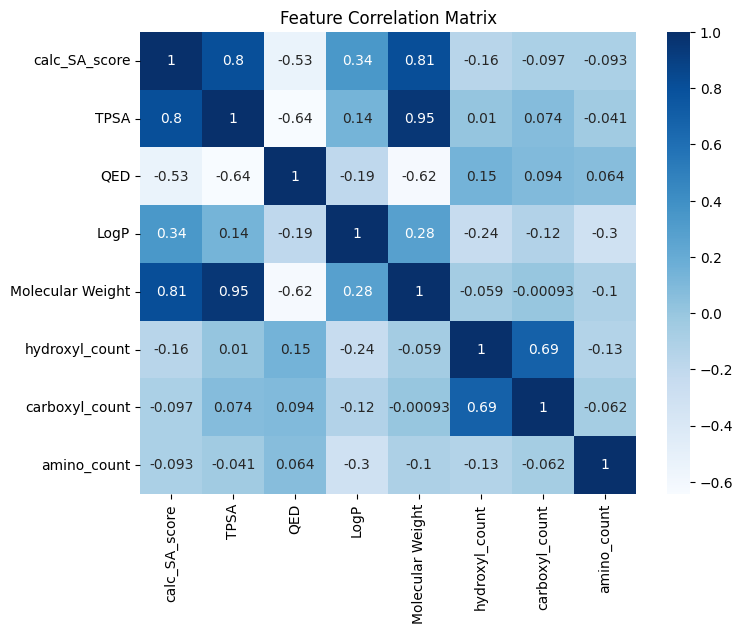

In [7]:
# Plot initial correlation matrix, exclude phosphate count 

plt.figure(figsize=(8,6))
sns.heatmap(linker[['calc_SA_score', 'TPSA', 'QED', 'LogP', 
                    'Molecular Weight', 'hydroxyl_count', 
                    'carboxyl_count', 'amino_count']].corr(),
            annot=True, cmap='Blues') #excluding phosphate count since there are 0 everywhere
plt.title("Feature Correlation Matrix")
plt.show()


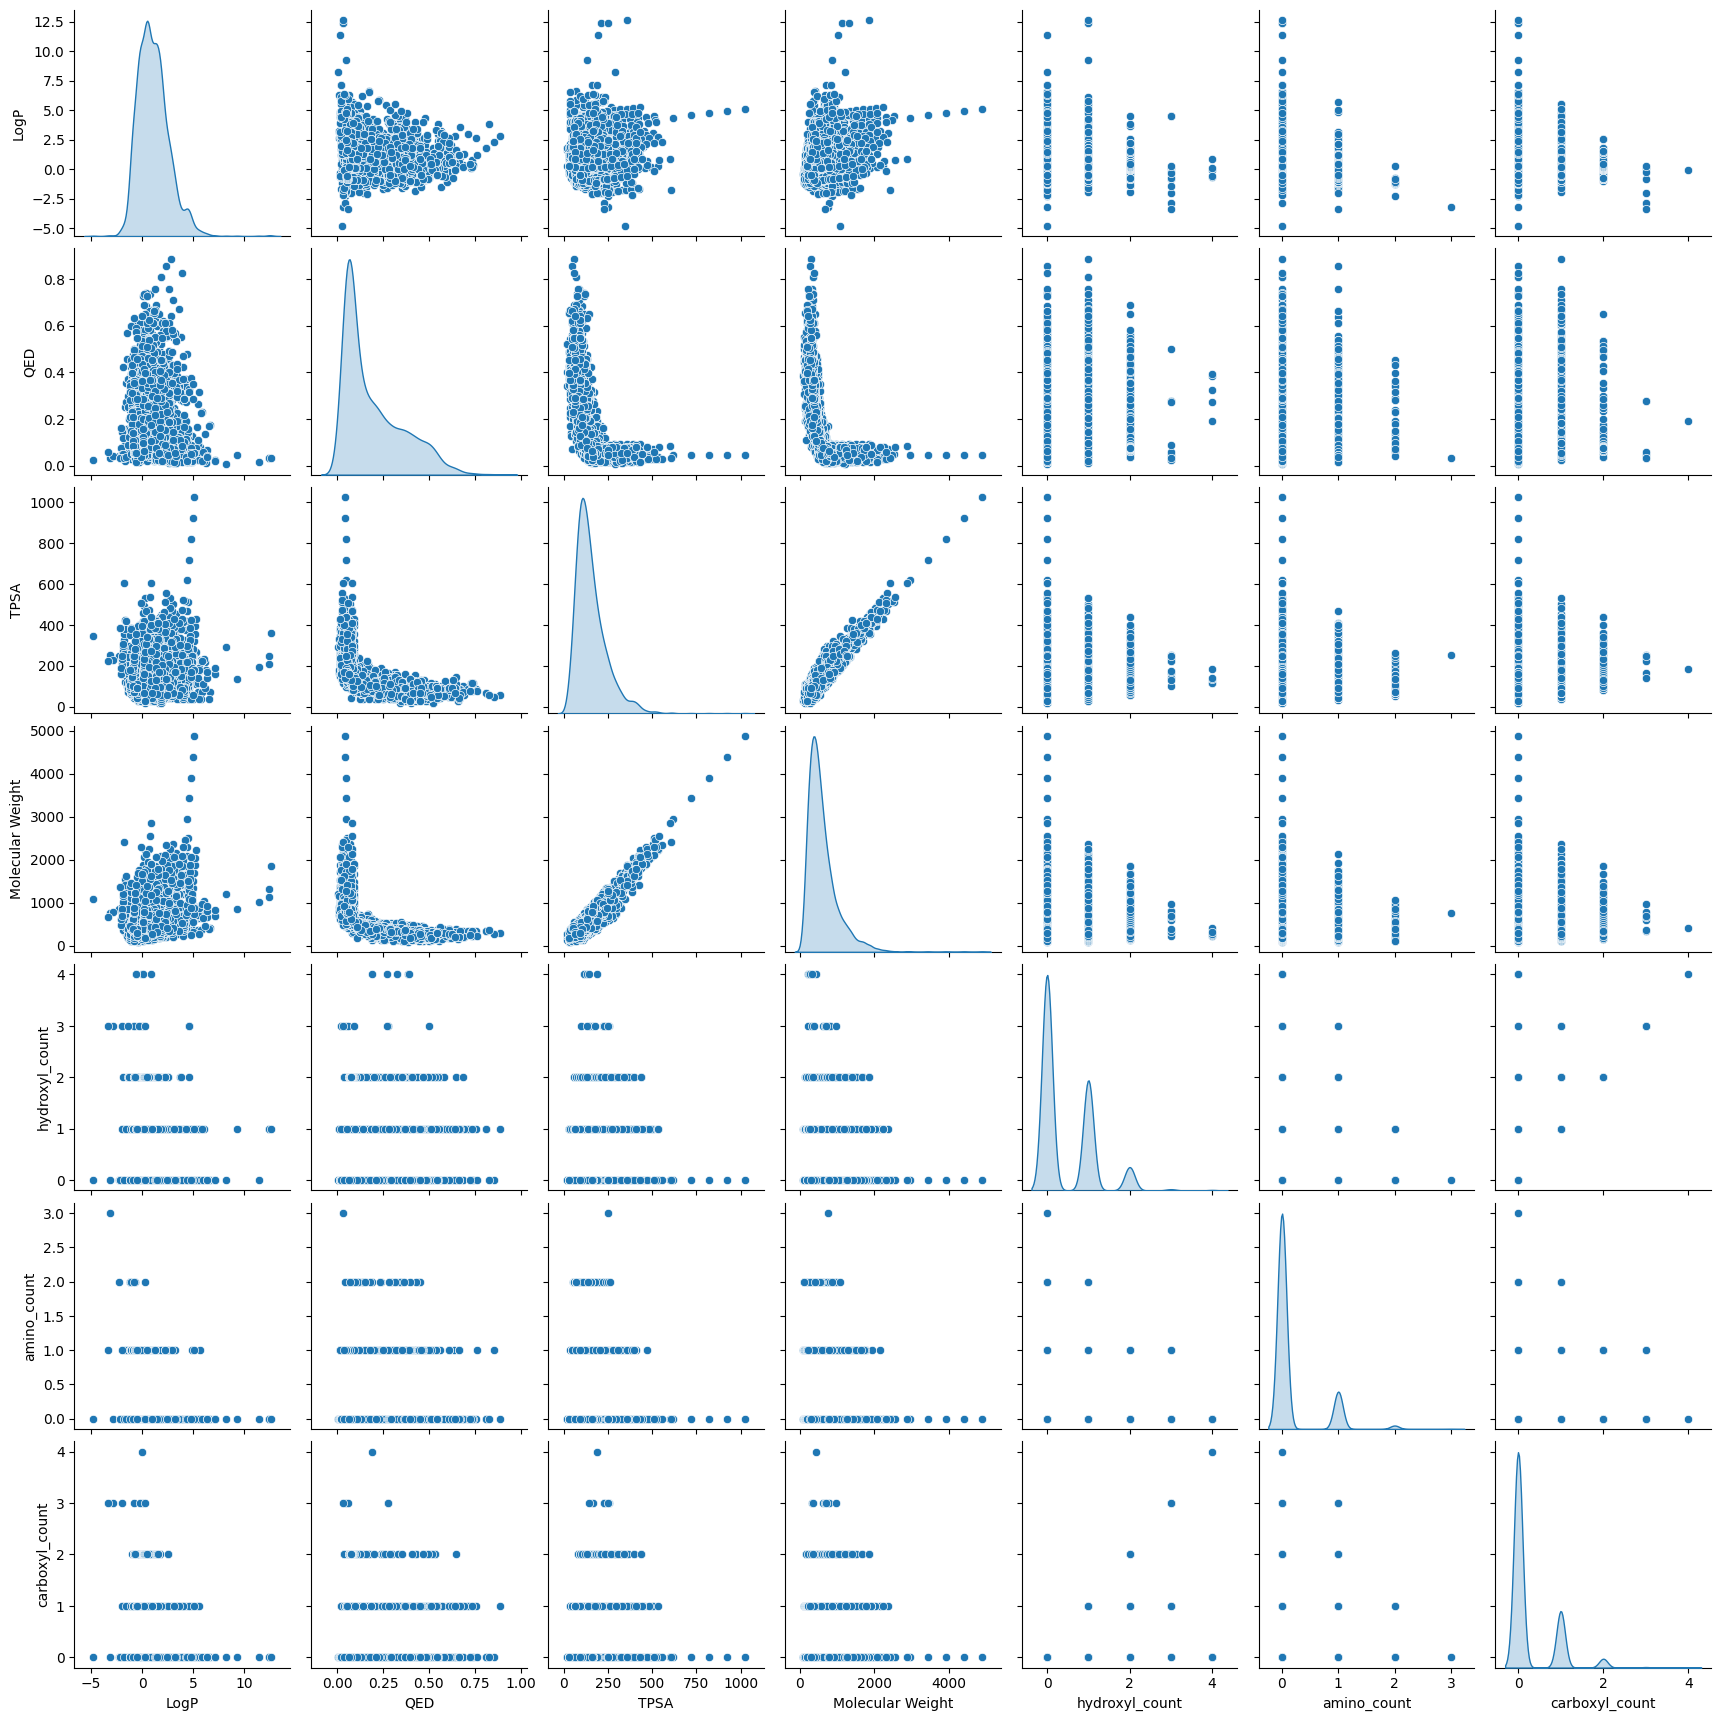

In [8]:
# Initial pair plot to visualize feature relationships (exclude phosphate counts)
sns.pairplot(linker[['LogP', 'QED', 'TPSA', 'Molecular Weight', 
                     'hydroxyl_count', 'amino_count', 'carboxyl_count']], diag_kind='kde')
plt.show()

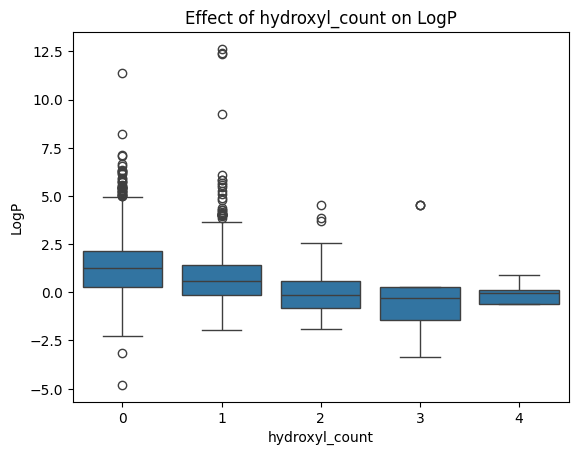

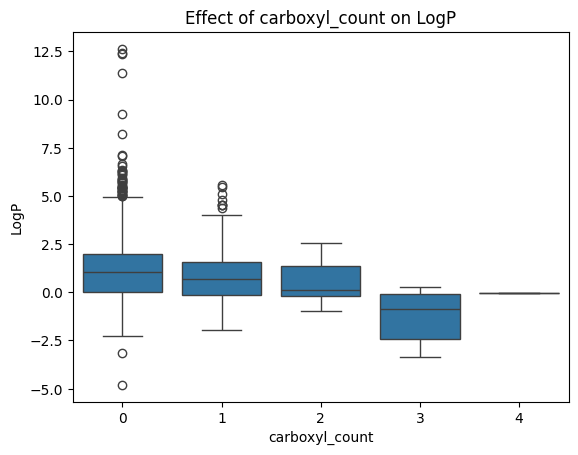

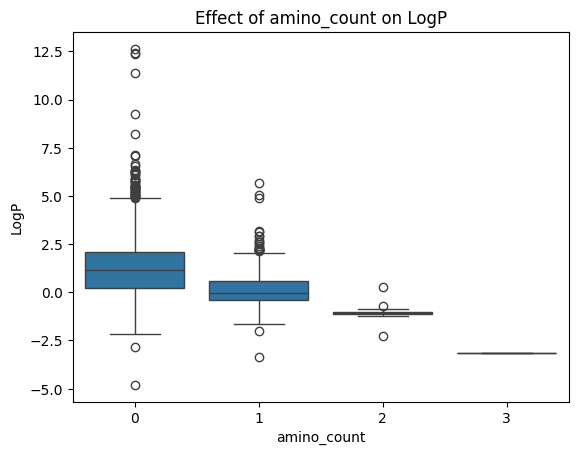

In [9]:
# Visualize effect of functional group counts on LogP (measure of hydrophilicity)
for group in ['hydroxyl_count', 'carboxyl_count', 'amino_count']:
    sns.boxplot(data=linker, x=group, y='LogP')
    plt.title(f'Effect of {group} on LogP')
    plt.show()

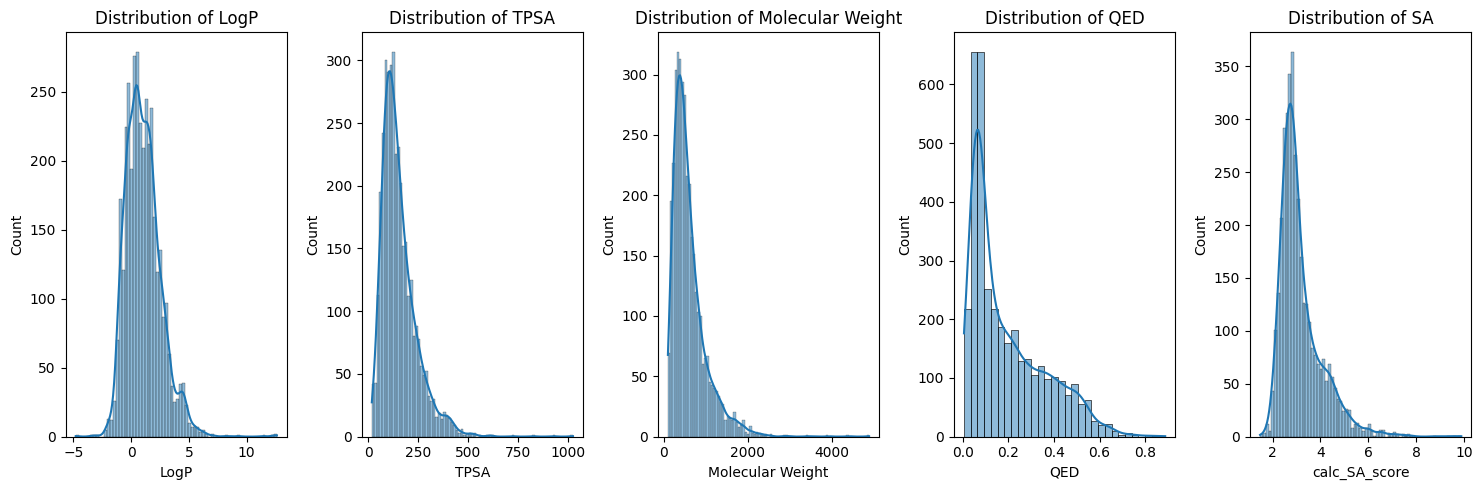

In [10]:
# Distribution of features in our data set
fig, axs = plt.subplots(1, 5, figsize=(15,5))
sns.histplot(linker['LogP'], kde=True, ax=axs[0])
axs[0].set_title('Distribution of LogP')

sns.histplot(linker['TPSA'], kde=True, ax=axs[1])
axs[1].set_title('Distribution of TPSA')

sns.histplot(linker['Molecular Weight'], kde=True, ax=axs[2])
axs[2].set_title('Distribution of Molecular Weight')

sns.histplot(linker['QED'], kde=True, ax=axs[3])
axs[3].set_title('Distribution of QED')

sns.histplot(linker['calc_SA_score'], kde=True, ax=axs[4])
axs[4].set_title('Distribution of SA')

plt.tight_layout()
plt.show()

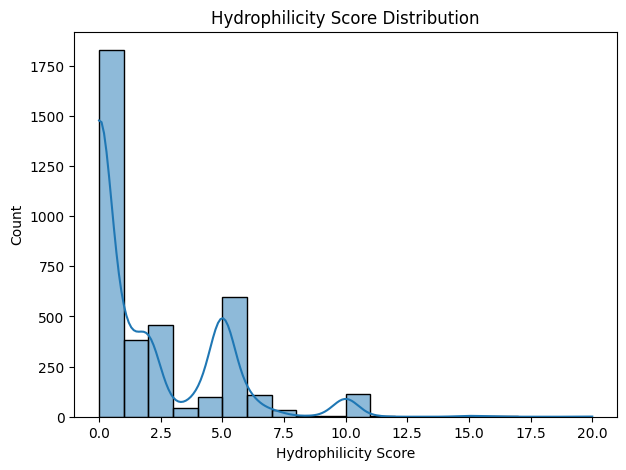

In [11]:
# Generate "Hydrophilicity Score" for our linkers based on functional group
    # add weight to each functional group based on hydrophilicity (higher weight = more hydrophilic)
linker['hydrophilicity_score'] = (
    4 * linker['phosphate_count'] +
    3 * linker['carboxyl_count'] +
    2 * linker['hydroxyl_count'] +
    1 * linker['amino_count']
)
linker['hydrophilicity_norm'] = linker['hydrophilicity_score'] / linker['Molecular Weight'] # Normalize by molecule size to avoid distortion of data

plt.figure(figsize=(7,5))
sns.histplot(linker['hydrophilicity_score'], bins=20, kde=True)
plt.title('Hydrophilicity Score Distribution')
plt.xlabel('Hydrophilicity Score')
plt.show()

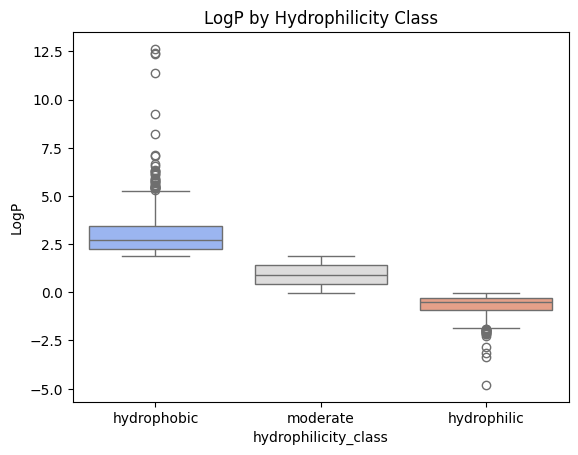

In [12]:
# Define hydrophilicity thresholds directly from LogP
low_thr = linker['LogP'].quantile(0.25)   # 25th percentile
high_thr = linker['LogP'].quantile(0.75)  # 75th percentile

# Create a hydrophilicity_class column based on LogP (specific to our dataset)
linker['hydrophilicity_class'] = linker['LogP'].apply(
    lambda x: 'hydrophilic' if x < low_thr else
              'hydrophobic' if x > high_thr else
              'moderate'
)

sns.boxplot(data=linker, x='hydrophilicity_class', y='LogP', hue='hydrophilicity_class', palette='coolwarm', legend = False)
plt.title('LogP by Hydrophilicity Class')
plt.show()

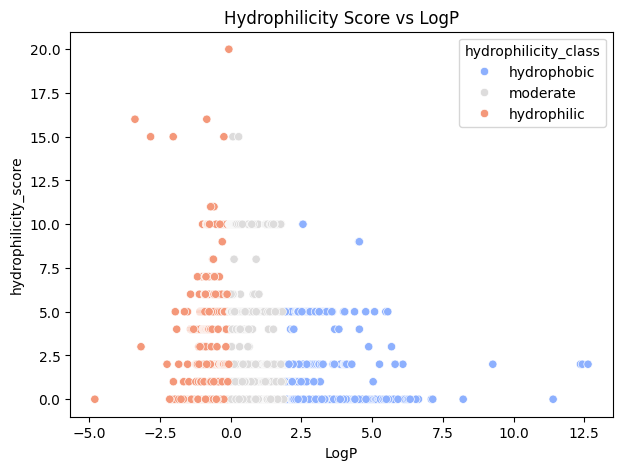

In [13]:
# Visualize separation of hydrophilicity on LogP:

plt.figure(figsize=(7,5))
sns.scatterplot(data=linker, x='LogP', y='hydrophilicity_score',
                hue='hydrophilicity_class', palette='coolwarm')
plt.title('Hydrophilicity Score vs LogP')
plt.show()


In [14]:
# Mean values of our features based on hydrophilicity:

linker.groupby('hydrophilicity_class')[['LogP', 'QED', 'TPSA', 'calc_SA_score']].mean()

,LogP,QED,TPSA,calc_SA_score
hydrophilicity_class,,,,
hydrophilic,-0.638781,0.218215,147.344863,2.878412
hydrophobic,3.070140,0.146406,177.585783,3.646701
moderate,0.912469,0.205262,147.026788,3.088463


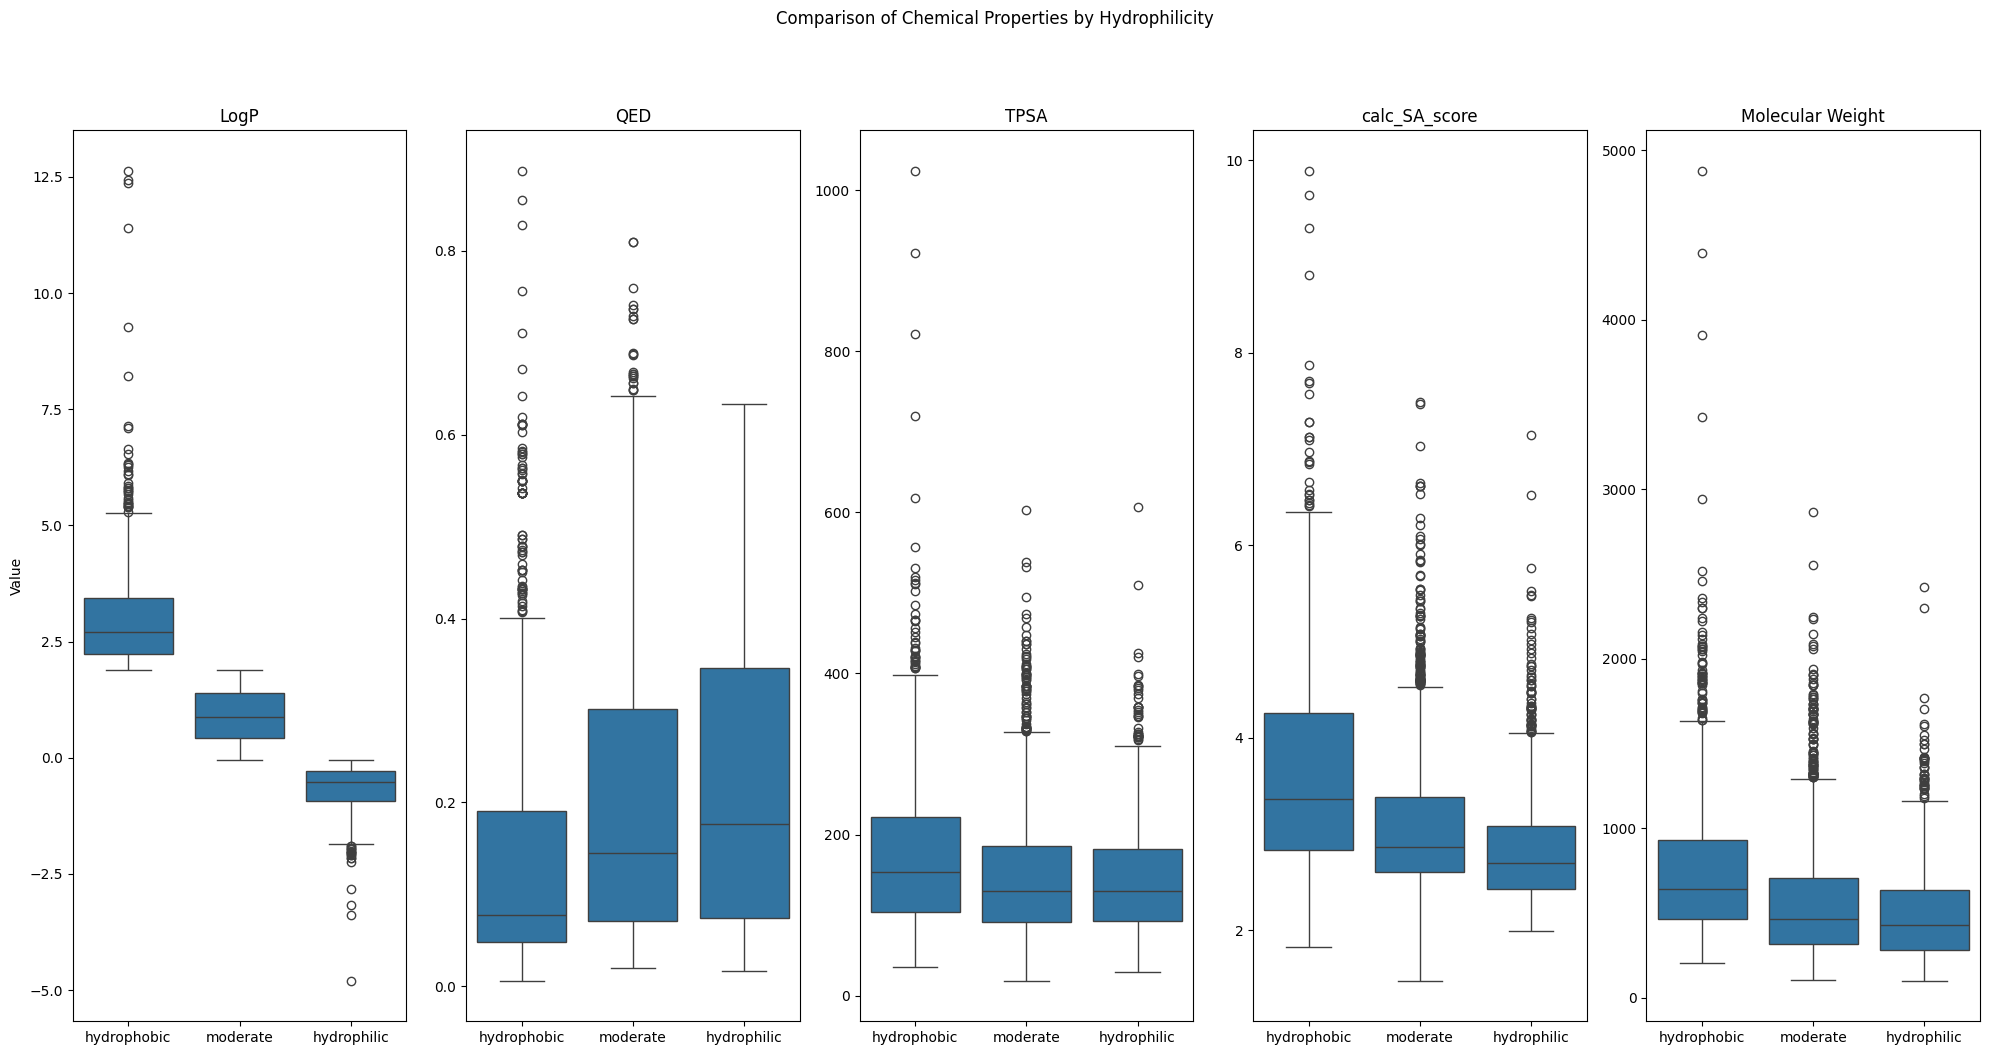

In [15]:
features = ['LogP', 'QED', 'TPSA', 'calc_SA_score', 'Molecular Weight']

plt.figure(figsize=(20, 10))

for i, feature in enumerate(features, 1):
    plt.subplot(1, 5, i)
    sns.boxplot(data=linker, x='hydrophilicity_class', y=feature,)
    plt.title(feature)
    plt.xlabel('')
    if i == 1:
        plt.ylabel('Value')
    else:
        plt.ylabel('')

plt.suptitle('Comparison of Chemical Properties by Hydrophilicity', y=1.05)
plt.tight_layout()
plt.show()

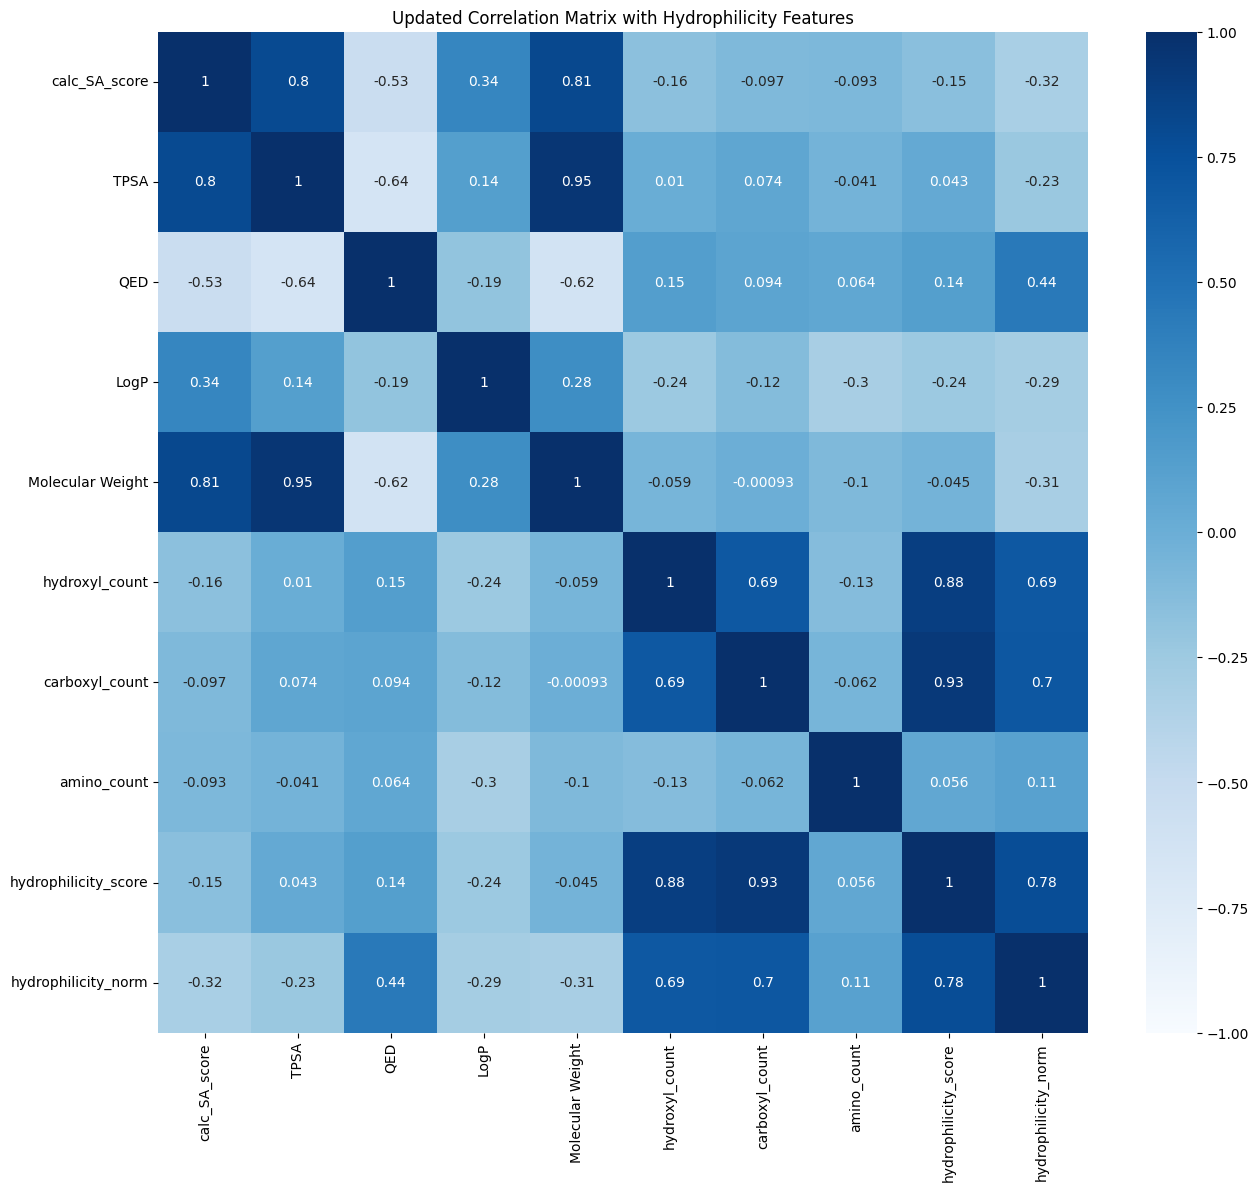

In [16]:
# Updated correlation matrix with hydrophilicity class and score added:

corr_features = [
    'calc_SA_score', 'TPSA', 'QED', 'LogP', 'Molecular Weight',
    'hydroxyl_count', 'carboxyl_count', 'amino_count',
    'hydrophilicity_score', 'hydrophilicity_norm'
]

plt.figure(figsize=(15,13))
sns.heatmap(linker[corr_features].corr(), annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title('Updated Correlation Matrix with Hydrophilicity Features')
plt.show()

In [ ]:
# Updated pair plots:

sns.pairplot(
    linker,
    vars=[
        'LogP', 'QED', 'TPSA', 'calc_SA_score',
        'Molecular Weight', 'hydrophilicity_score', 'hydrophilicity_norm'
    ],
    hue='hydrophilicity_class',       # color by hydrophilic/hydrophobic/moderate
    palette='coolwarm',
    diag_kind='kde'
)
plt.suptitle('Pairwise Relationships with Hydrophilicity Features', y=1.02)
plt.show()
